<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Power_grid_vulnerability_mapping_via_cascading_failure_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Power Grid Vulnerability and Cascading Failure Simulation
This notebook models a power grid to analyze its resilience against targeted and random attacks using percolation theory and cascading failure simulations.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Generate a synthetic power grid-like graph
# Power grids often exhibit small-world and scale-free properties
n = 500  # Number of nodes (substations)
m = 2    # Number of random edges to add for each new node
p = 0.1  # Probability of adding a triangle

G = nx.powerlaw_cluster_graph(n, m, p)

print(f"Generated graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Generated graph with 500 nodes and 996 edges.


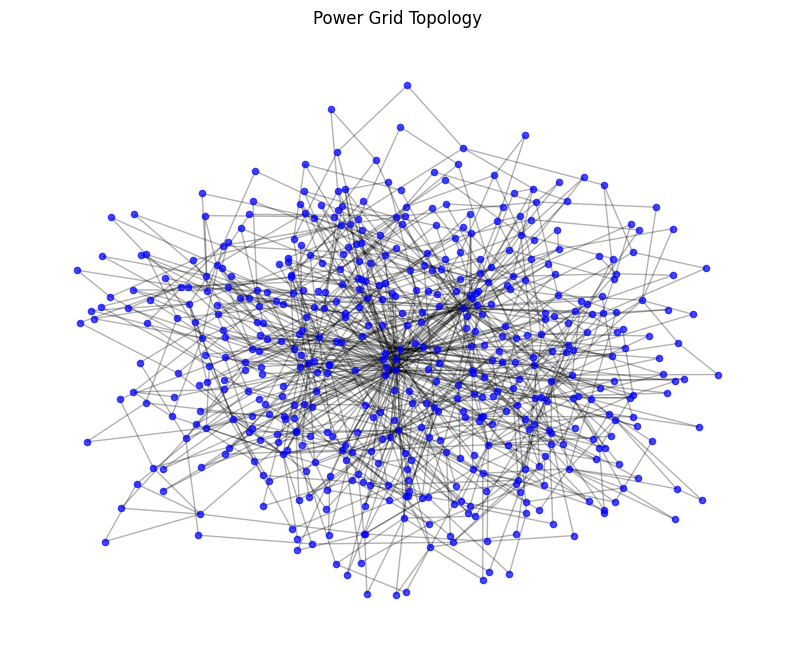

In [2]:
def plot_grid(graph, title="Power Grid Topology"):
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(graph, k=0.15, seed=42)
    nx.draw_networkx_nodes(graph, pos, node_size=20, node_color='blue', alpha=0.7)
    nx.draw_networkx_edges(graph, pos, alpha=0.3)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_grid(G)

Simulating random failure...
Simulating targeted attack...


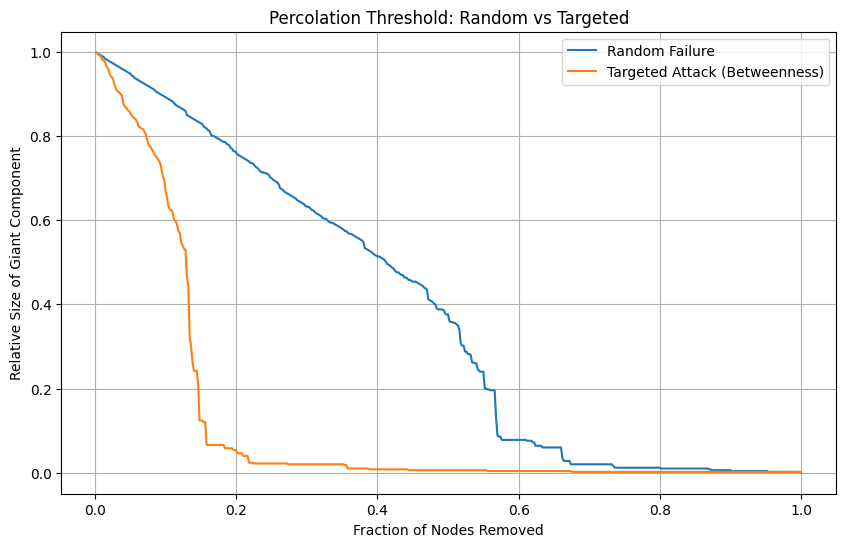

In [3]:
def get_giant_component_size(graph):
    if len(graph) == 0:
        return 0
    return len(max(nx.connected_components(graph), key=len))

def simulate_percolation(graph, attack_type='random'):
    temp_graph = graph.copy()
    nodes = list(temp_graph.nodes())

    if attack_type == 'targeted':
        # Target nodes with high betweenness centrality
        centrality = nx.betweenness_centrality(temp_graph)
        nodes_to_remove = sorted(centrality, key=centrality.get, reverse=True)
    else:
        nodes_to_remove = nodes.copy()
        random.shuffle(nodes_to_remove)

    fractions = []
    gc_sizes = []
    initial_size = get_giant_component_size(temp_graph)

    for i, node in enumerate(nodes_to_remove):
        temp_graph.remove_node(node)
        fractions.append((i + 1) / len(nodes))
        gc_sizes.append(get_giant_component_size(temp_graph) / initial_size)

    return fractions, gc_sizes

print("Simulating random failure...")
rand_frac, rand_gc = simulate_percolation(G, 'random')

print("Simulating targeted attack...")
target_frac, target_gc = simulate_percolation(G, 'targeted')

plt.figure(figsize=(10, 6))
plt.plot(rand_frac, rand_gc, label='Random Failure')
plt.plot(target_frac, target_gc, label='Targeted Attack (Betweenness)')
plt.xlabel('Fraction of Nodes Removed')
plt.ylabel('Relative Size of Giant Component')
plt.title('Percolation Threshold: Random vs Targeted')
plt.legend()
plt.grid(True)
plt.show()

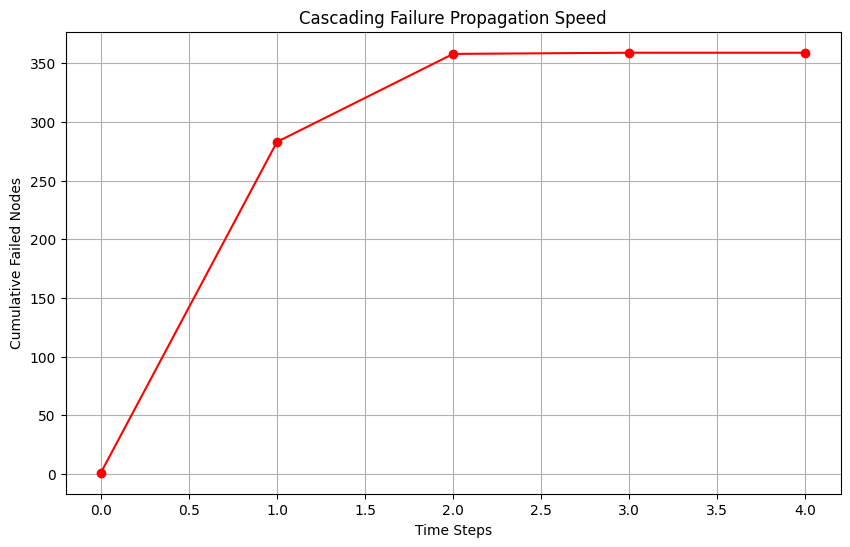

Total nodes failed: 359 out of 500


In [4]:
def simulate_cascade(graph, target_node, tolerance=1.2):
    # Initialize load based on betweenness centrality
    load = nx.betweenness_centrality(graph)
    capacity = {n: load[n] * tolerance for n in graph.nodes()}

    active_nodes = set(graph.nodes())
    failed_nodes = {target_node}
    active_nodes.remove(target_node)

    history = [len(failed_nodes)]
    new_failures = [target_node]

    while new_failures:
        current_step_failures = []
        # In a real grid, load would redistribute.
        # Here we simulate the effect by recalculating centrality on the remaining graph
        if len(active_nodes) <= 1: break

        current_graph = graph.subgraph(active_nodes)
        current_load = nx.betweenness_centrality(current_graph)

        for node in list(active_nodes):
            # If current load exceeds original capacity, the node fails
            if current_load.get(node, 0) > capacity[node]:
                current_step_failures.append(node)

        for node in current_step_failures:
            active_nodes.remove(node)
            failed_nodes.add(node)

        new_failures = current_step_failures
        history.append(len(failed_nodes))

    return history

# Find the most critical node to trigger a cascade
centrality = nx.betweenness_centrality(G)
critical_node = max(centrality, key=centrality.get)

cascade_history = simulate_cascade(G, critical_node)

plt.figure(figsize=(10, 6))
plt.plot(range(len(cascade_history)), cascade_history, marker='o', color='red')
plt.xlabel('Time Steps')
plt.ylabel('Cumulative Failed Nodes')
plt.title('Cascading Failure Propagation Speed')
plt.grid(True)
plt.show()

print(f"Total nodes failed: {cascade_history[-1]} out of {n}")